# 🔩 Surface Defect Classifier — Inference
Predictions on new steel surface images using the trained EfficientNetB0 model.


## 1. Imports


In [1]:
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt


## 2. Configuration


In [2]:
IMG_SIZE              = 224
MODEL_PATH            = "steel_defect_model.keras"
CLASS_NAMES_PATH      = "class_names.json"


## 3. Load Model & Class Names


In [3]:
model = tf.keras.models.load_model(MODEL_PATH)

with open(CLASS_NAMES_PATH, 'r') as f:
    class_names = json.load(f)

print("Model loaded successfully.")
print("Classes:", class_names)


Model loaded successfully.
Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


## 4. Prediction Function


In [4]:
def predict_image(img_path: str):
    """Run inference on a single image and display results.

    Args:
        img_path: Path to the input image file.

    Returns:
        (predicted_class: str, confidence: float)
    """
    # Load & preprocess
    img       = tf.keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = tf.keras.applications.efficientnet.preprocess_input(
                    np.expand_dims(img_array, axis=0)
                )

    # Inference
    preds           = model.predict(img_array, verbose=0)[0]
    predicted_idx   = int(np.argmax(preds))
    predicted_class = class_names[predicted_idx]
    confidence      = float(np.max(preds))

    # Results table
    results_df = (
        pd.DataFrame({
            'Class'          : class_names,
            'Probability'    : preds.round(4),
            'Percentage (%)' : (preds * 100).round(2),
        })
        .sort_values('Probability', ascending=False)
        .reset_index(drop=True)
    )

    # Display
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.title(
        f'Prediction : {predicted_class}\nConfidence : {confidence:.2%}',
        fontsize=13, fontweight='bold',
    )
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print('\nClass Probabilities:\n')
    display(results_df)

    return predicted_class, confidence


## 5. Run Predictions



──────────────────────────────────────────────────
 Image: /content/Inference_IMG/crazing.png
──────────────────────────────────────────────────


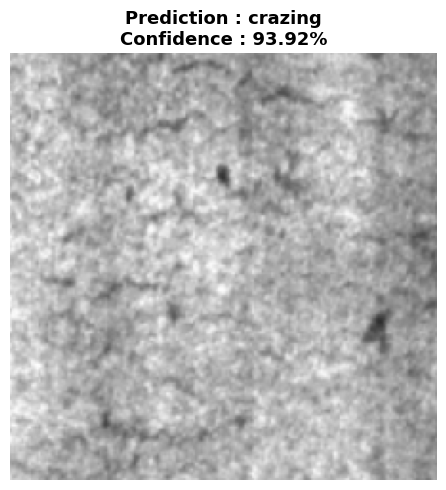


Class Probabilities:



,Class,Probability,Percentage (%)
0,crazing,0.9392,93.919998
1,rolled-in_scale,0.0164,1.640000
2,patches,0.0149,1.490000
3,pitted_surface,0.0132,1.320000
4,scratches,0.0102,1.020000
5,inclusion,0.0061,0.610000



──────────────────────────────────────────────────
 Image: /content/Inference_IMG/patches.png
──────────────────────────────────────────────────


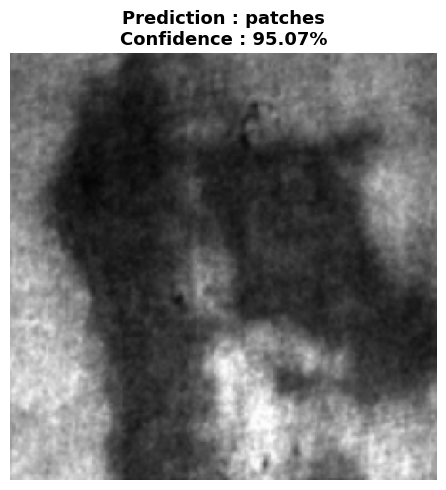


Class Probabilities:



,Class,Probability,Percentage (%)
0,patches,0.9507,95.07
1,inclusion,0.0137,1.37
2,scratches,0.0118,1.18
3,crazing,0.0103,1.03
4,rolled-in_scale,0.0083,0.83
5,pitted_surface,0.0052,0.52



──────────────────────────────────────────────────
 Image: /content/Inference_IMG/patches1.png
──────────────────────────────────────────────────


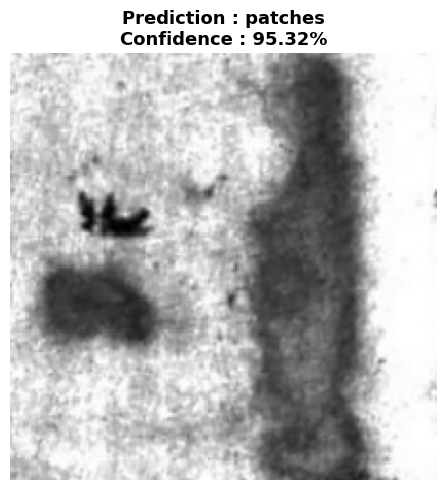


Class Probabilities:



,Class,Probability,Percentage (%)
0,patches,0.9532,95.32
1,scratches,0.0124,1.24
2,crazing,0.0097,0.97
3,inclusion,0.0091,0.91
4,rolled-in_scale,0.0083,0.83
5,pitted_surface,0.0072,0.72



──────────────────────────────────────────────────
 Image: /content/Inference_IMG/PittedSurface.png
──────────────────────────────────────────────────


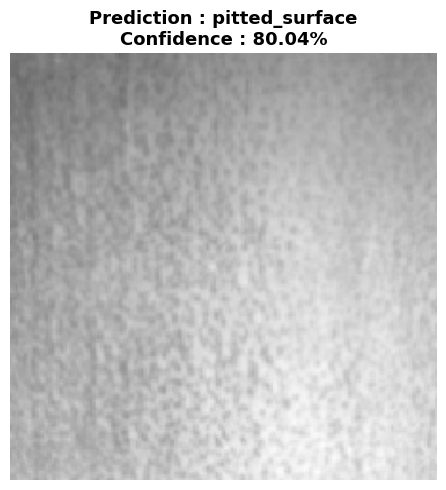


Class Probabilities:



,Class,Probability,Percentage (%)
0,pitted_surface,0.8004,80.040001
1,crazing,0.0712,7.120000
2,inclusion,0.0712,7.120000
3,patches,0.0294,2.940000
4,scratches,0.0194,1.940000
5,rolled-in_scale,0.0084,0.840000



──────────────────────────────────────────────────
 Image: /content/Inference_IMG/PittedSurface1.png
──────────────────────────────────────────────────


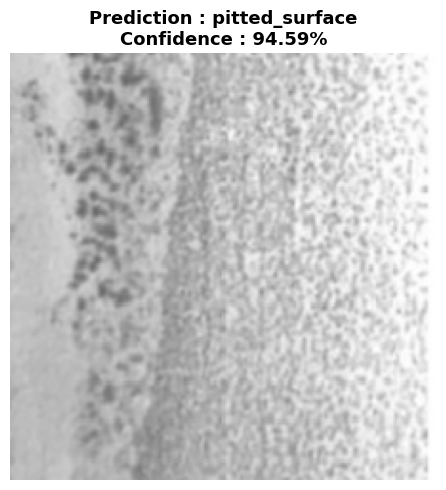


Class Probabilities:



,Class,Probability,Percentage (%)
0,pitted_surface,0.9459,94.589996
1,scratches,0.0151,1.510000
2,crazing,0.0143,1.430000
3,inclusion,0.0115,1.150000
4,patches,0.0094,0.940000
5,rolled-in_scale,0.0038,0.380000



──────────────────────────────────────────────────
 Image: /content/Inference_IMG/RolledIn.png
──────────────────────────────────────────────────


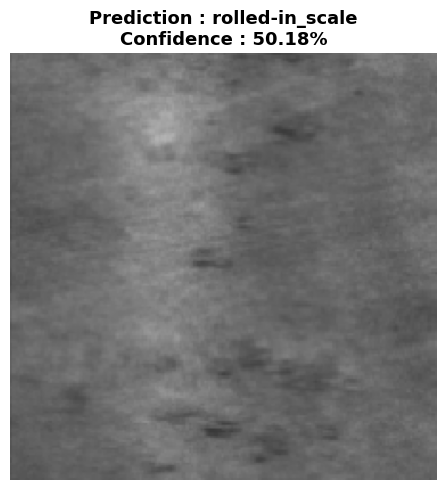


Class Probabilities:



,Class,Probability,Percentage (%)
0,rolled-in_scale,0.5018,50.18
1,patches,0.2173,21.73
2,inclusion,0.1740,17.40
3,scratches,0.0442,4.42
4,pitted_surface,0.0341,3.41
5,crazing,0.0285,2.85



──────────────────────────────────────────────────
 Image: /content/Inference_IMG/RolledIn1.png
──────────────────────────────────────────────────


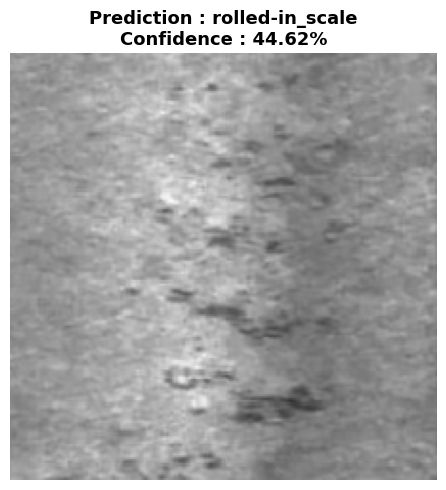


Class Probabilities:



,Class,Probability,Percentage (%)
0,rolled-in_scale,0.4462,44.619999
1,crazing,0.3356,33.560001
2,pitted_surface,0.0621,6.210000
3,patches,0.0614,6.140000
4,scratches,0.0538,5.380000
5,inclusion,0.0409,4.090000



──────────────────────────────────────────────────
 Image: /content/Inference_IMG/scraches.png
──────────────────────────────────────────────────


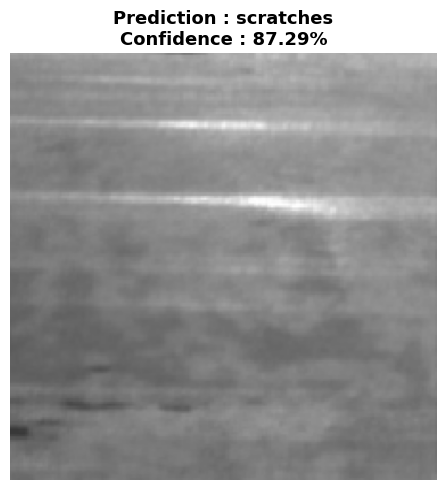


Class Probabilities:



,Class,Probability,Percentage (%)
0,scratches,0.8729,87.290001
1,rolled-in_scale,0.0517,5.170000
2,crazing,0.0266,2.660000
3,patches,0.0261,2.610000
4,inclusion,0.0126,1.260000
5,pitted_surface,0.0102,1.020000



──────────────────────────────────────────────────
 Image: /content/Inference_IMG/scraches.png
──────────────────────────────────────────────────


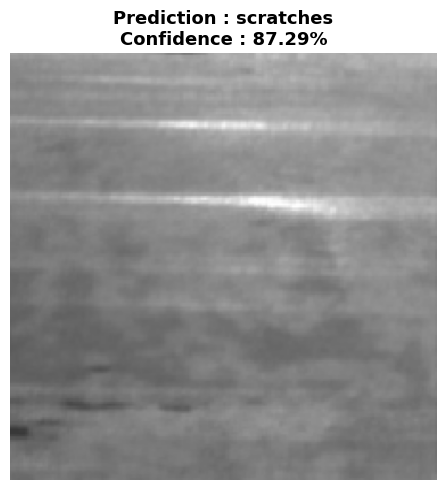


Class Probabilities:



,Class,Probability,Percentage (%)
0,scratches,0.8729,87.290001
1,rolled-in_scale,0.0517,5.170000
2,crazing,0.0266,2.660000
3,patches,0.0261,2.610000
4,inclusion,0.0126,1.260000
5,pitted_surface,0.0102,1.020000



──────────────────────────────────────────────────
 Image: /content/Inference_IMG/inclusion.png
──────────────────────────────────────────────────


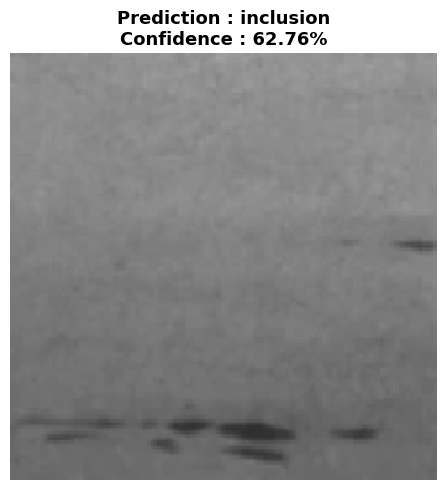


Class Probabilities:



,Class,Probability,Percentage (%)
0,inclusion,0.6276,62.759998
1,scratches,0.2150,21.500000
2,patches,0.0510,5.100000
3,rolled-in_scale,0.0401,4.010000
4,crazing,0.0381,3.810000
5,pitted_surface,0.0282,2.820000


In [10]:
test_images = [
    '/content/Inference_IMG/crazing.png',
    '/content/Inference_IMG/patches.png',
    '/content/Inference_IMG/patches1.png',
    '/content/Inference_IMG/PittedSurface.png',
    '/content/Inference_IMG/PittedSurface1.png',
    '/content/Inference_IMG/RolledIn.png',
    '/content/Inference_IMG/RolledIn1.png',
    '/content/Inference_IMG/scraches.png',
    '/content/Inference_IMG/scraches.png',
    '/content/Inference_IMG/inclusion.png'
]

for img_path in test_images:
    print(f"\n{'─' * 50}")
    print(f' Image: {img_path}')
    print(f"{'─' * 50}")
    predict_image(img_path)


In [12]:
!zip -qr all_files.zip steel_defect_model.keras class_names.json Inference_IMG/

from google.colab import files
files.download('all_files.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>